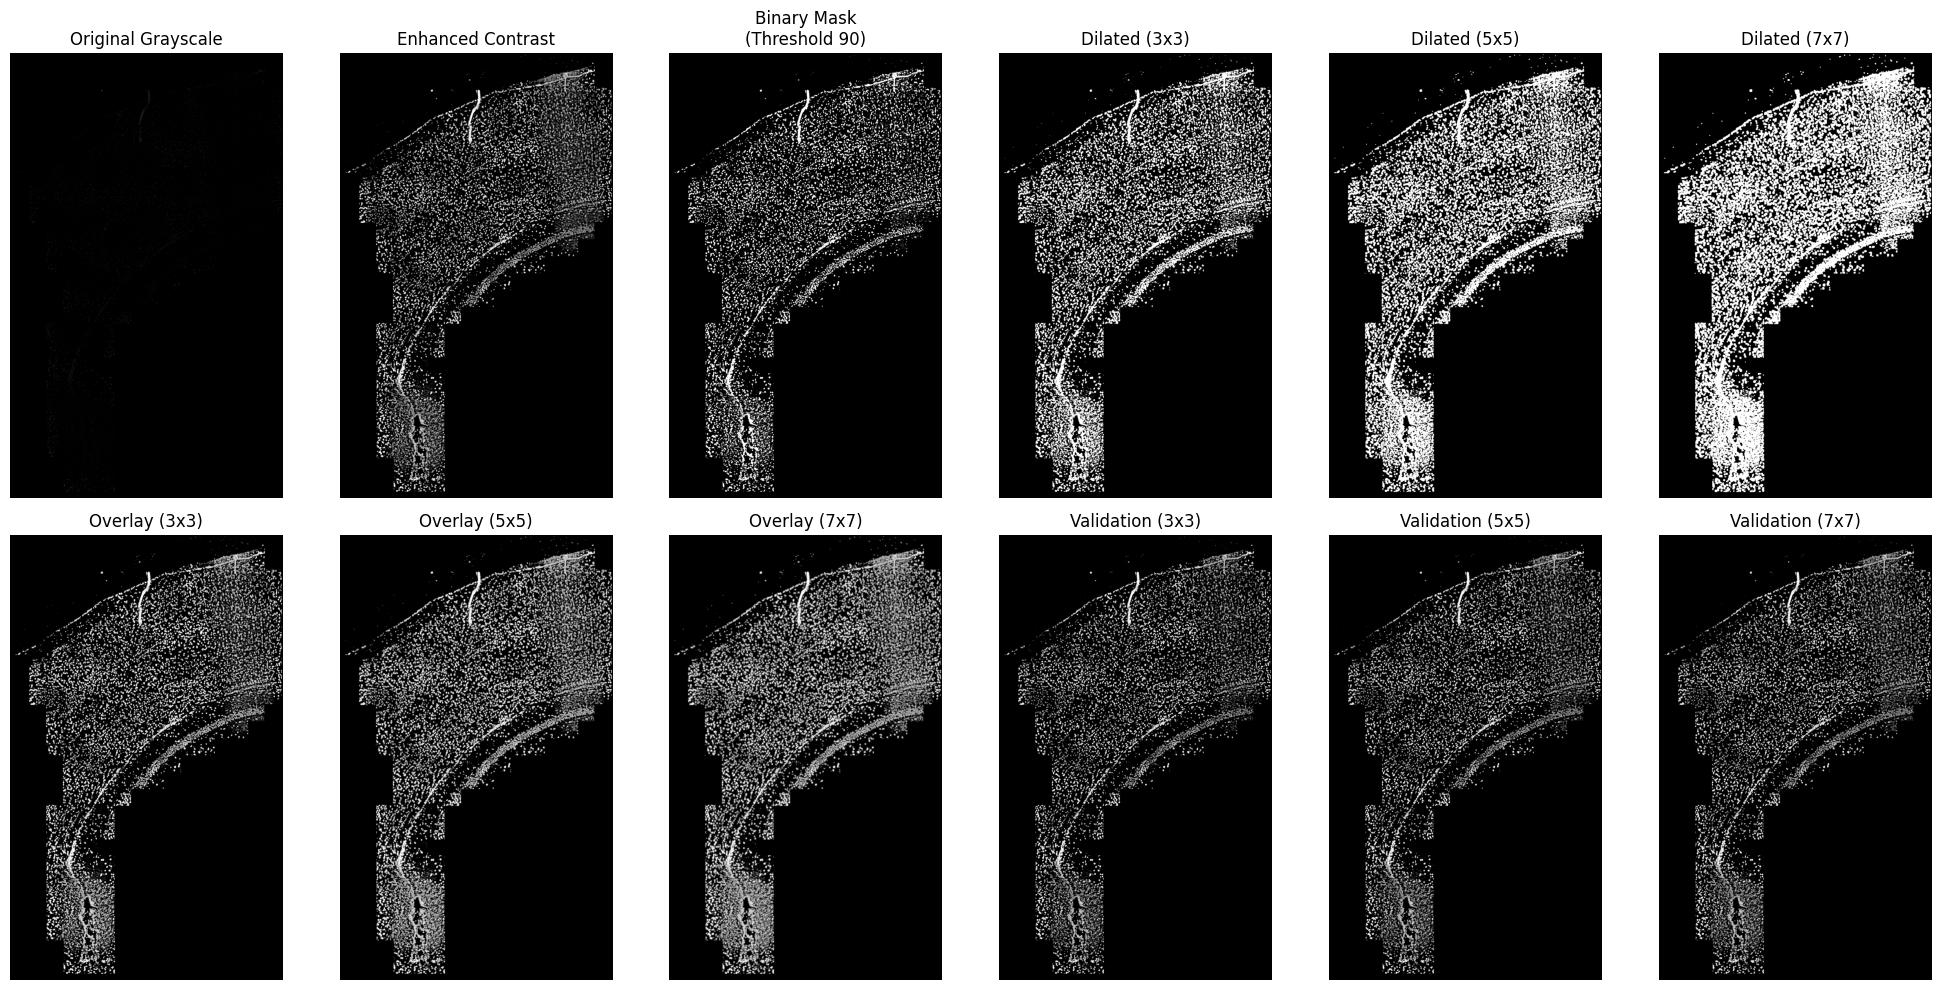

In [6]:
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Step 1: Load the osmFISH image data
file_to_load = "/kaggle/input/merfish-multiplexed-smfish-osmfish-3dataset/supplemental_data_ssam_2019/osmFISH/raw_data/im_nuc_small.pickle"
with open(file_to_load, 'rb') as f:
    nuclei_data = pickle.load(f)

# Convert nuclei data to uint8 for processing
if len(nuclei_data.shape) == 3:
    gray_image = cv2.cvtColor(nuclei_data, cv2.COLOR_RGB2GRAY)
else:
    gray_image = nuclei_data
gray_image = ((gray_image - gray_image.min()) / (gray_image.max() - gray_image.min()) * 255).astype('uint8')

# Step 2: Apply histogram equalization to enhance contrast
enhanced_image = cv2.equalizeHist(gray_image)

# Step 3: Apply Thresholding with a fixed value
threshold_value = 90
_, binary_mask = cv2.threshold(enhanced_image, threshold_value, 255, cv2.THRESH_BINARY)

# Step 4: Apply Dilation with multiple kernel sizes
kernel_3x3 = np.ones((3, 3), np.uint8)
kernel_5x5 = np.ones((5, 5), np.uint8)
kernel_7x7 = np.ones((7, 7), np.uint8)

dilated_3x3 = cv2.dilate(binary_mask, kernel_3x3, iterations=1)
dilated_5x5 = cv2.dilate(binary_mask, kernel_5x5, iterations=1)
dilated_7x7 = cv2.dilate(binary_mask, kernel_7x7, iterations=1)

# Step 5: Overlay the dilated masks on the enhanced image
overlay_3x3 = cv2.addWeighted(enhanced_image, 0.7, dilated_3x3, 0.3, 0)
overlay_5x5 = cv2.addWeighted(enhanced_image, 0.7, dilated_5x5, 0.3, 0)
overlay_7x7 = cv2.addWeighted(enhanced_image, 0.7, dilated_7x7, 0.3, 0)

# Step 6: Validate the results by multiplying the enhanced image with the binary masks
validation_3x3 = cv2.bitwise_and(enhanced_image, enhanced_image, mask=dilated_3x3)
validation_5x5 = cv2.bitwise_and(enhanced_image, enhanced_image, mask=dilated_5x5)
validation_7x7 = cv2.bitwise_and(enhanced_image, enhanced_image, mask=dilated_7x7)

# Horizontal Visualization
fig, axs = plt.subplots(2, 6, figsize=(20, 10))

# Row 1: Original, enhanced, binary mask
axs[0, 0].imshow(gray_image, cmap='gray')
axs[0, 0].set_title("Original Grayscale")
axs[0, 0].axis('off')

axs[0, 1].imshow(enhanced_image, cmap='gray')
axs[0, 1].set_title("Enhanced Contrast")
axs[0, 1].axis('off')

axs[0, 2].imshow(binary_mask, cmap='gray')
axs[0, 2].set_title(f"Binary Mask\n(Threshold {threshold_value})")
axs[0, 2].axis('off')

# Row 1: Dilated masks
axs[0, 3].imshow(dilated_3x3, cmap='gray')
axs[0, 3].set_title("Dilated (3x3)")
axs[0, 3].axis('off')

axs[0, 4].imshow(dilated_5x5, cmap='gray')
axs[0, 4].set_title("Dilated (5x5)")
axs[0, 4].axis('off')

axs[0, 5].imshow(dilated_7x7, cmap='gray')
axs[0, 5].set_title("Dilated (7x7)")
axs[0, 5].axis('off')

# Row 2: Overlays
axs[1, 0].imshow(overlay_3x3, cmap='gray')
axs[1, 0].set_title("Overlay (3x3)")
axs[1, 0].axis('off')

axs[1, 1].imshow(overlay_5x5, cmap='gray')
axs[1, 1].set_title("Overlay (5x5)")
axs[1, 1].axis('off')

axs[1, 2].imshow(overlay_7x7, cmap='gray')
axs[1, 2].set_title("Overlay (7x7)")
axs[1, 2].axis('off')

# Row 2: Validations
axs[1, 3].imshow(validation_3x3, cmap='gray')
axs[1, 3].set_title("Validation (3x3)")
axs[1, 3].axis('off')

axs[1, 4].imshow(validation_5x5, cmap='gray')
axs[1, 4].set_title("Validation (5x5)")
axs[1, 4].axis('off')

axs[1, 5].imshow(validation_7x7, cmap='gray')
axs[1, 5].set_title("Validation (7x7)")
axs[1, 5].axis('off')

plt.tight_layout()
plt.show()
